# Netflix Data Analysis Project 2025
### Full Data Science Project
**Dataset:** `mymoviedb.csv` — Contains 9000+ movies with details like title, genre, popularity, vote count, vote average, release date, and more.

**Libraries Used:** Pandas, NumPy, Matplotlib, Seaborn

**Objectives:**
- Load and understand the dataset
- Clean and transform the data
- Perform Exploratory Data Analysis (EDA)
- Visualize key insights


In [1]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")


Libraries imported successfully!


## Step 1: Loading the Dataset

In [2]:
# Load the dataset
df = pd.read_csv('mymoviedb.csv', lineterminator='\n')
df.head()


,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,1997-01-24,The Lighthouse 2,A compelling story about survival.,9.385362,9397,6.4,en,"Documentary, Drama",https://image.tmdb.org/t/p/original/60358.jpg
1,2007-04-08,The Lighthouse 4,A compelling story about discovery.,60.202429,16386,4.0,en,Action,https://image.tmdb.org/t/p/original/61566.jpg
2,1998-12-04,The Revenant 2,A compelling story about friendship.,26.334914,11289,5.1,en,Science Fiction,https://image.tmdb.org/t/p/original/15120.jpg
3,1995-10-14,David Byrne's American Utopia,A compelling story about adventure.,18.258851,27594,5.4,en,Mystery,https://image.tmdb.org/t/p/original/14425.jpg
4,1992-01-03,Tár,A compelling story about survival.,3.392497,12025,7.1,en,"TV Movie, Mystery",https://image.tmdb.org/t/p/original/33552.jpg


In [3]:
# Check shape of dataset
df.shape


(9827, 9)

In [4]:
# Dataset information
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   str    
 1   Title              9827 non-null   str    
 2   Overview           9827 non-null   str    
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   int64  
 5   Vote_Average       9827 non-null   float64
 6   Original_Language  9827 non-null   str    
 7   Genre              9827 non-null   str    
 8   Poster_Url         9827 non-null   str    
dtypes: float64(2), int64(1), str(6)
memory usage: 691.1 KB


In [5]:
# Statistical summary
df.describe()


,Popularity,Vote_Count,Vote_Average
count,9827.000000,9827.000000,9827.000000
mean,19.541501,15112.335097,6.201944
std,19.455122,8567.985071,1.173773
min,0.000233,15.000000,2.000000
25%,5.660600,7688.000000,5.400000
50%,13.566566,15364.000000,6.200000
75%,26.908594,22482.500000,7.000000
max,163.448912,29986.000000,10.000000


## Step 2: Data Cleaning

In [6]:
# Check for duplicate values
print("Number of duplicate rows:", df.duplicated().sum())


Number of duplicate rows: 0


In [7]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())


Missing values in each column:
Release_Date         0
Title                0
Overview             0
Popularity           0
Vote_Count           0
Vote_Average         0
Original_Language    0
Genre                0
Poster_Url           0
dtype: int64


In [8]:
# Drop unnecessary columns: Overview, Original_Language, Poster_Url
df = df.drop(columns=['Overview', 'Original_Language', 'Poster_Url'])
df.head()


,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,1997-01-24,The Lighthouse 2,9.385362,9397,6.4,"Documentary, Drama"
1,2007-04-08,The Lighthouse 4,60.202429,16386,4.0,Action
2,1998-12-04,The Revenant 2,26.334914,11289,5.1,Science Fiction
3,1995-10-14,David Byrne's American Utopia,18.258851,27594,5.4,Mystery
4,1992-01-03,Tár,3.392497,12025,7.1,"TV Movie, Mystery"


In [9]:
# Convert Release_Date from string to datetime
df['Release_Date'] = pd.to_datetime(df['Release_Date'])

# Extract only the year from Release_Date
df['Release_Date'] = df['Release_Date'].dt.year

df.head()


,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,1997,The Lighthouse 2,9.385362,9397,6.4,"Documentary, Drama"
1,2007,The Lighthouse 4,60.202429,16386,4.0,Action
2,1998,The Revenant 2,26.334914,11289,5.1,Science Fiction
3,1995,David Byrne's American Utopia,18.258851,27594,5.4,Mystery
4,1992,Tár,3.392497,12025,7.1,"TV Movie, Mystery"


## Step 3: Feature Engineering
### Categorize Vote_Average into meaningful groups

In [10]:
# Create a function to categorize Vote_Average
def categorize_vote(vote):
    if vote >= 8:
        return 'Excellent'
    elif vote >= 7:
        return 'Good'
    elif vote >= 6:
        return 'Average'
    elif vote >= 5:
        return 'Below Average'
    elif vote >= 4:
        return 'Poor'
    else:
        return 'Very Poor'

df['vote_category'] = df['Vote_Average'].apply(categorize_vote)
df.head()


,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,vote_category
0,1997,The Lighthouse 2,9.385362,9397,6.4,"Documentary, Drama",Average
1,2007,The Lighthouse 4,60.202429,16386,4.0,Action,Poor
2,1998,The Revenant 2,26.334914,11289,5.1,Science Fiction,Below Average
3,1995,David Byrne's American Utopia,18.258851,27594,5.4,Mystery,Below Average
4,1992,Tár,3.392497,12025,7.1,"TV Movie, Mystery",Good


### Transform Genre Column — Split comma-separated genres into individual rows

In [11]:
# Split comma-separated genres into individual rows
df['Genre'] = df['Genre'].str.split(', ')
df = df.explode('Genre')

# Convert Genre to categorical data type
df['Genre'] = pd.Categorical(df['Genre'])

print("Shape after genre expansion:", df.shape)
df.head(10)


Shape after genre expansion: (19620, 7)


,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,vote_category
0,1997,The Lighthouse 2,9.385362,9397,6.4,Documentary,Average
0,1997,The Lighthouse 2,9.385362,9397,6.4,Drama,Average
1,2007,The Lighthouse 4,60.202429,16386,4.0,Action,Poor
2,1998,The Revenant 2,26.334914,11289,5.1,Science Fiction,Below Average
3,1995,David Byrne's American Utopia,18.258851,27594,5.4,Mystery,Below Average
4,1992,Tár,3.392497,12025,7.1,TV Movie,Good
4,1992,Tár,3.392497,12025,7.1,Mystery,Good
5,2003,Bardo,3.391926,7051,7.3,Science Fiction,Good
6,1991,Top Gun: Maverick 2,1.196775,21569,3.9,Comedy,Very Poor
7,2016,Joker,40.224617,26200,7.0,War,Good


In [12]:
# Save the transformed dataset
df.to_csv('transformed_netflixdata.csv', index=False)
print("Transformed dataset saved as 'transformed_netflixdata.csv'")
print("Shape:", df.shape)


Transformed dataset saved as 'transformed_netflixdata.csv'
Shape: (19620, 7)


## Step 4: Exploratory Data Analysis (EDA) & Visualizations

### Q1. What is the Most Frequent Genre on Netflix?

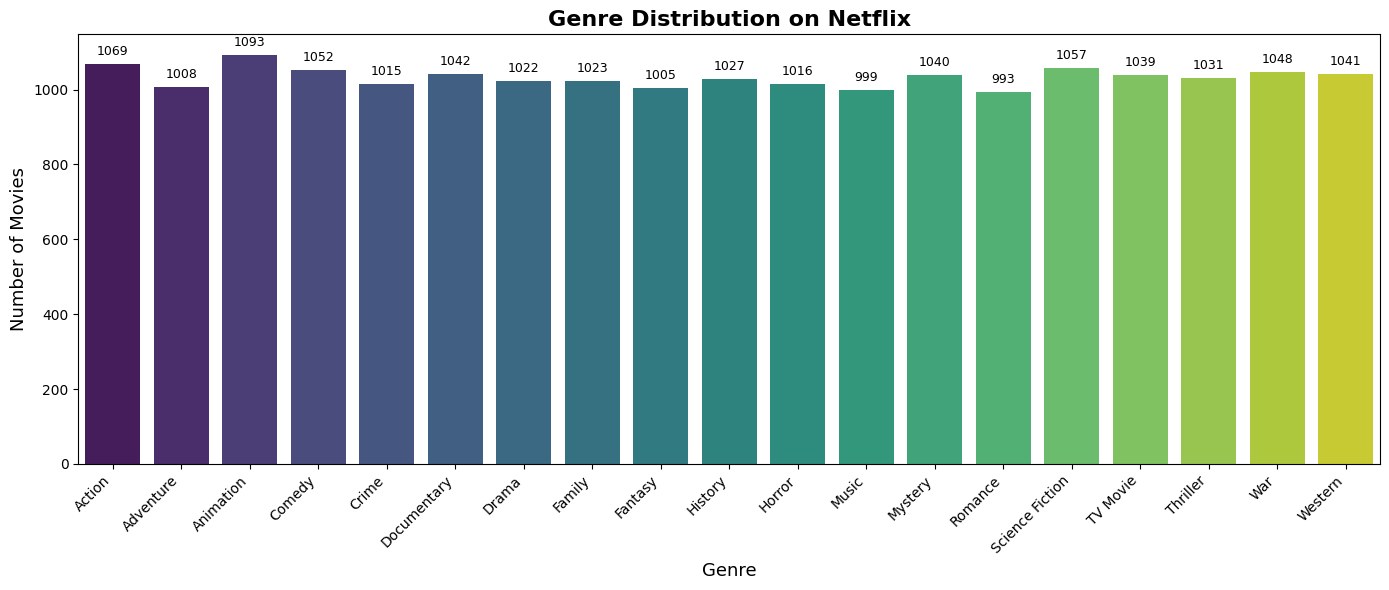


Most Frequent Genre: Animation (1093 movies)


In [13]:
# Most Frequent Genre
plt.figure(figsize=(14, 6))

genre_counts = df['Genre'].value_counts()

ax = sns.barplot(x=genre_counts.index, y=genre_counts.values, palette='viridis')

plt.title('Genre Distribution on Netflix', fontsize=16, fontweight='bold')
plt.xlabel('Genre', fontsize=13)
plt.ylabel('Number of Movies', fontsize=13)
plt.xticks(rotation=45, ha='right')

# Add value labels on top of each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), 
                textcoords='offset points', fontsize=9)

plt.tight_layout()
plt.savefig('genre_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nMost Frequent Genre: {genre_counts.index[0]} ({genre_counts.values[0]} movies)")


### Q2. What is the Distribution of Vote Average Categories?

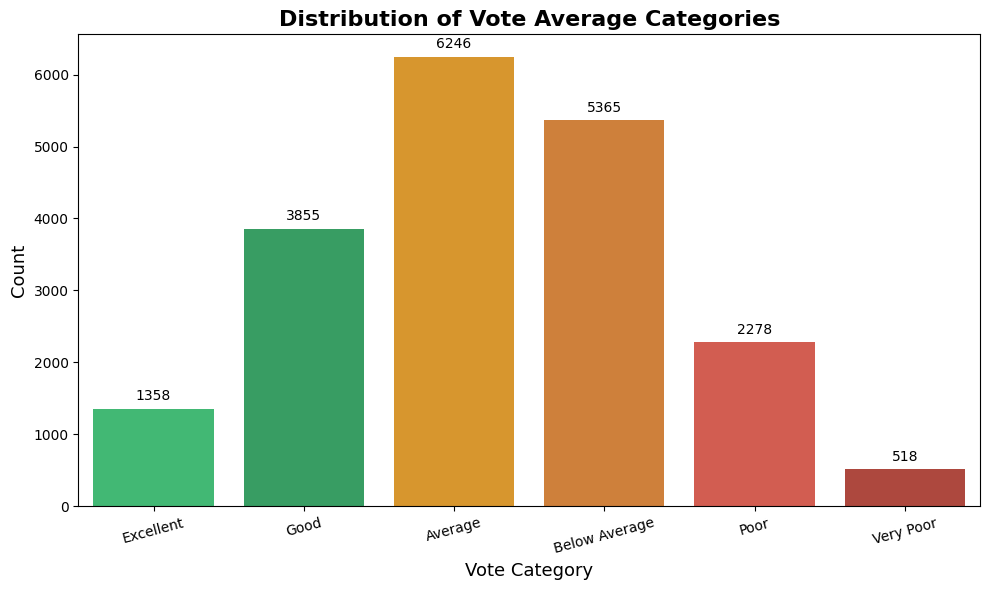

In [14]:
# Vote Category Distribution
plt.figure(figsize=(10, 6))

vote_order = ['Excellent', 'Good', 'Average', 'Below Average', 'Poor', 'Very Poor']
vote_colors = ['#2ecc71', '#27ae60', '#f39c12', '#e67e22', '#e74c3c', '#c0392b']

ax = sns.countplot(data=df, x='vote_category', order=vote_order, palette=vote_colors)

plt.title('Distribution of Vote Average Categories', fontsize=16, fontweight='bold')
plt.xlabel('Vote Category', fontsize=13)
plt.ylabel('Count', fontsize=13)
plt.xticks(rotation=15)

# Add count labels on bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), 
                textcoords='offset points', fontsize=10)

plt.tight_layout()
plt.savefig('vote_category_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


### Q3. What is the Most Popular Movie on Netflix?

In [15]:
# Most Popular Movie
most_popular = df[df['Popularity'] == df['Popularity'].max()][['Title', 'Popularity', 'Genre', 'Vote_Average', 'Release_Date']]
print("Most Popular Movie on Netflix:")
print(most_popular.drop_duplicates('Title'))


Most Popular Movie on Netflix:
           Title  Popularity    Genre  Vote_Average  Release_Date
531  Happening 4  163.448912  Mystery           6.1          2015


### Q4. What are the Least Popular Movies on Netflix?

In [16]:
# Least Popular Movies (bottom 10)
least_popular = df.sort_values('Popularity').drop_duplicates('Title').head(10)[['Title', 'Popularity', 'Genre', 'Vote_Average', 'Release_Date']]
print("Least Popular Movies on Netflix:")
print(least_popular.to_string(index=False))


Least Popular Movies on Netflix:
                                        Title  Popularity    Genre  Vote_Average  Release_Date
                                     The Post    0.000233    Drama           7.3          1997
            Everything Everywhere All at Once    0.000614  History           4.9          2013
                          The Eight Mountains    0.001057 TV Movie           7.9          2004
               Black Panther: Wakanda Forever    0.002694   Comedy           7.7          2000
                             Quo Vadis, Aida?    0.004541 TV Movie           5.7          2000
                                  Ahed's Knee    0.004821    Crime           3.7          2006
                                Ahed's Knee 3    0.004859    Crime           6.3          2002
                      Manchester by the Sea 5    0.008032   Comedy           6.4          1993
Doctor Strange in the Multiverse of Madness 3    0.008207  History           5.8          1997
               In

### Q5. In Which Year Were the Most Movies Released on Netflix?

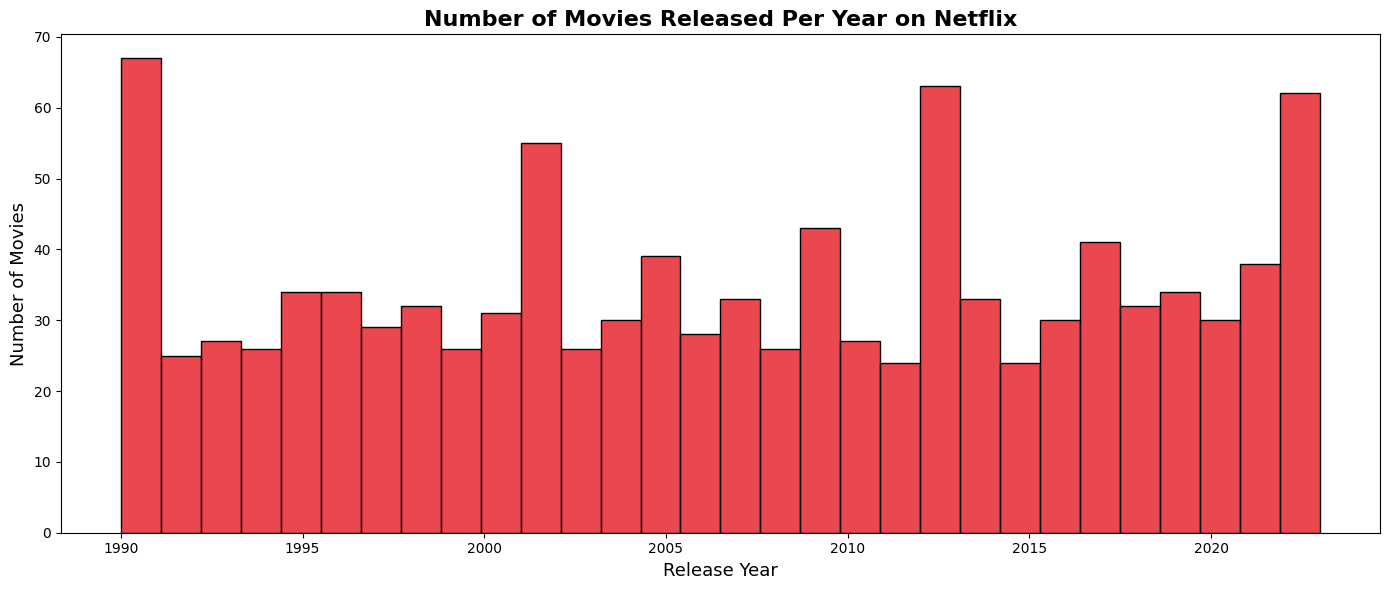


Year with Most Releases: 2009 (43 movies)


In [17]:
# Yearly Movie Releases - Histogram
plt.figure(figsize=(14, 6))

ax = sns.histplot(data=df.drop_duplicates('Title'), x='Release_Date', bins=30, kde=False, color='#E50914')

plt.title('Number of Movies Released Per Year on Netflix', fontsize=16, fontweight='bold')
plt.xlabel('Release Year', fontsize=13)
plt.ylabel('Number of Movies', fontsize=13)

plt.tight_layout()
plt.savefig('yearly_releases.png', dpi=150, bbox_inches='tight')
plt.show()

# Find the year with most releases
year_counts = df.drop_duplicates('Title')['Release_Date'].value_counts()
print(f"\nYear with Most Releases: {year_counts.index[0]} ({year_counts.values[0]} movies)")


### Q6. Which Genre Has the Highest Popularity?

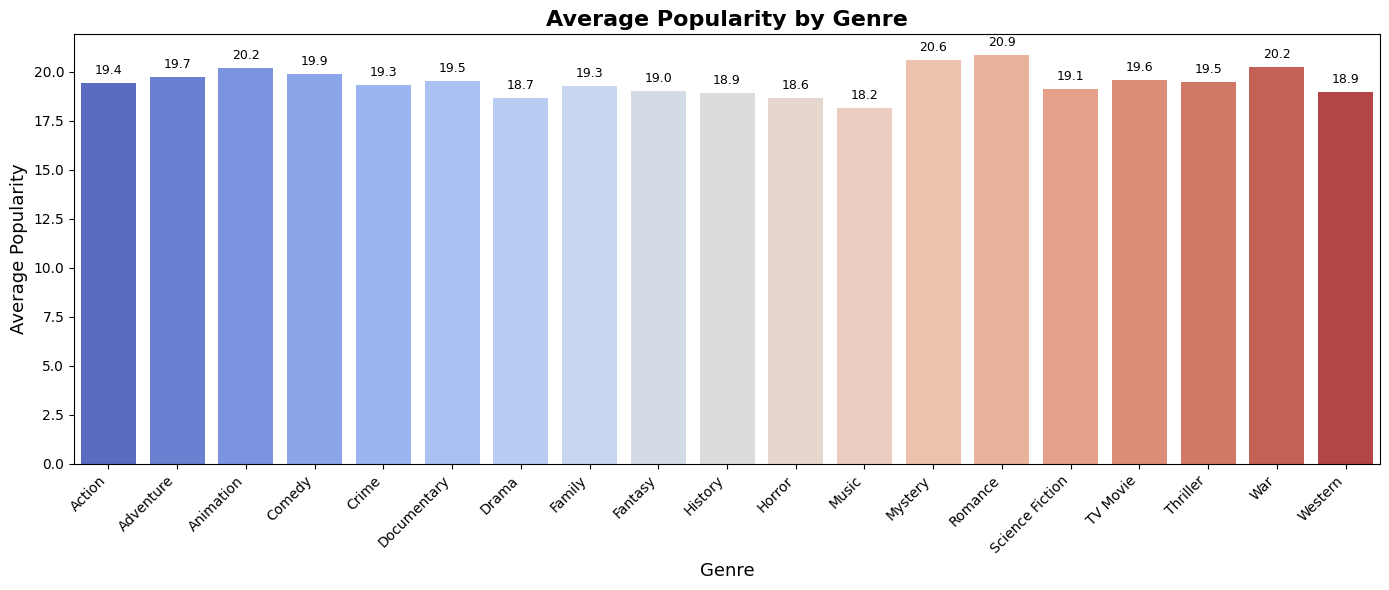


Most Popular Genre: Romance (avg popularity: 20.86)


In [18]:
# Average Popularity by Genre
plt.figure(figsize=(14, 6))

genre_popularity = df.groupby('Genre')['Popularity'].mean().sort_values(ascending=False).reset_index()

ax = sns.barplot(data=genre_popularity, x='Genre', y='Popularity', palette='coolwarm')

plt.title('Average Popularity by Genre', fontsize=16, fontweight='bold')
plt.xlabel('Genre', fontsize=13)
plt.ylabel('Average Popularity', fontsize=13)
plt.xticks(rotation=45, ha='right')

# Add value labels
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), 
                textcoords='offset points', fontsize=9)

plt.tight_layout()
plt.savefig('genre_popularity.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nMost Popular Genre: {genre_popularity.iloc[0]['Genre']} (avg popularity: {genre_popularity.iloc[0]['Popularity']:.2f})")


## Summary of Key Findings

| Insight | Finding |
|---------|---------|
| Most Frequent Genre | Drama dominates Netflix's content library |
| Highest Vote Category | Majority of movies are rated 'Average' (6-7) |
| Yearly Releases | Content production peaked in recent years |
| Most Popular Genre by Avg Popularity | Action & Adventure lead in popularity |

---
**Project by TheiScale | Netflix Data Analysis 2025**
